# Logistic Regression for ECG Heartbeat Classification

## 1. Model Objective and Rationale

Research question: **Can a linear classification model distinguish N, S, V and F using the 18 engineered ECG features?** Logistic Regression is an inexpensive linear baseline with multiclass probabilities and standardised coefficients, but it is not fully clinically interpretable.

## 2. Setup and Reproducibility

Set the fixed seed, repository-relative paths, class order, and reusable metric function.

In [1]:
from pathlib import Path
import json, time, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
RANDOM_SEED=42; CLASS_ORDER=["N","S","V","F"]
ROOT=Path.cwd().resolve()
if ROOT.name=="notebooks": ROOT=ROOT.parent
DATA=ROOT/"data/processed"; METRICS=ROOT/"results/metrics"; PRED=ROOT/"results/predictions"; MODELS=ROOT/"results/models"; FIGURES=ROOT/"figures"
for path in (METRICS,PRED,MODELS,FIGURES): path.mkdir(parents=True,exist_ok=True)
previous_payload=json.loads((METRICS/"logistic_regression_metrics.json").read_text())
DROP=["beat_id","record_id","annotation_sample","annotation_symbol","mapped_class","split","selected_lead"]

In [2]:
def metric_summary(y_true, predictions):
    precision, recall, macro_f1, _ = precision_recall_fscore_support(y_true,predictions,labels=CLASS_ORDER,average="macro",zero_division=0)
    weighted_f1 = precision_recall_fscore_support(y_true,predictions,labels=CLASS_ORDER,average="weighted",zero_division=0)[2]
    return {"accuracy":accuracy_score(y_true,predictions),"macro_precision":precision,"macro_recall":recall,"macro_f1":macro_f1,"weighted_f1":weighted_f1}

## 3. Load Training Data

Load only the training feature table and display its class composition.

In [3]:
train=pd.read_csv(DATA/"classical_train.csv",dtype={"record_id":str})
features=[column for column in train.columns if column not in DROP]
X_train=train[features].to_numpy(); y_train=train["mapped_class"].to_numpy()
train_distribution=train["mapped_class"].value_counts().reindex(CLASS_ORDER).rename_axis("Class").reset_index(name="Training beats")
train_distribution["Percentage"]=train_distribution["Training beats"]/len(train)
display(train_distribution); print("Training shape:",train.shape,"Features:",len(features))

,Class,Training beats,Percentage
0,N,63594,0.894871
1,S,2037,0.028664
2,V,5025,0.070710
3,F,409,0.005755


Training shape: (71065, 25) Features: 18


## 4. Load Validation Data

Load validation separately so tuning data are visibly distinct from training and test.

In [4]:
validation=pd.read_csv(DATA/"classical_val.csv",dtype={"record_id":str})
X_validation=validation[features].to_numpy(); y_validation=validation["mapped_class"].to_numpy()
validation_distribution=validation["mapped_class"].value_counts().reindex(CLASS_ORDER).rename_axis("Class").reset_index(name="Validation beats")
validation_distribution["Percentage"]=validation_distribution["Validation beats"]/len(validation)
display(validation_distribution); print("Validation shape:",validation.shape)

,Class,Validation beats,Percentage
0,N,13623,0.895602
1,S,310,0.020380
2,V,911,0.059891
3,F,367,0.024127


Validation shape: (15211, 25)


## 5. Verify Training and Validation Data

Check feature identity, finite values, allowed classes, and record separation before fitting.

In [5]:
train_ids=set((DATA/"train_records.txt").read_text().split()); validation_ids=set((DATA/"validation_records.txt").read_text().split())
data_checks=pd.DataFrame({"Check":["Training rows align with labels","Validation rows align with labels","Same feature columns","No NaN training values","No NaN validation values","All values finite","Classes limited to N/S/V/F"],"Result":["PASS" if len(X_train)==len(y_train) else "FAIL","PASS" if len(X_validation)==len(y_validation) else "FAIL","PASS" if features==[c for c in validation.columns if c not in DROP] else "FAIL","PASS" if not np.isnan(X_train).any() else "FAIL","PASS" if not np.isnan(X_validation).any() else "FAIL","PASS" if np.isfinite(X_train).all() and np.isfinite(X_validation).all() else "FAIL","PASS" if set(y_train)|set(y_validation)<=set(CLASS_ORDER) else "FAIL"]})
display(data_checks); assert data_checks.Result.eq("PASS").all()

,Check,Result
0,Training rows align with labels,PASS
1,Validation rows align with labels,PASS
2,Same feature columns,PASS
3,No NaN training values,PASS
4,No NaN validation values,PASS
5,All values finite,PASS
6,Classes limited to N/S/V/F,PASS


## 6. Standardise Features

Fit `StandardScaler` on training only, then reuse it for validation and later test data to prevent leakage.

In [6]:
scaler=StandardScaler()
scaler.fit(X_train)

StandardScaler()

In [7]:
X_train_scaled=scaler.transform(X_train)
X_validation_scaled=scaler.transform(X_validation)

In [8]:
selected_scaling=["rr_previous_s","rr_local_mean_s","qrs_local_range","max_abs_slope"]
idx=[features.index(f) for f in selected_scaling]
scaling_check=pd.DataFrame({"Feature":selected_scaling,"Original mean":X_train[:,idx].mean(0),"Original SD":X_train[:,idx].std(0),"Scaled mean":X_train_scaled[:,idx].mean(0),"Scaled SD":X_train_scaled[:,idx].std(0)})
display(scaling_check)

,Feature,Original mean,Original SD,Scaled mean,Scaled SD
0,rr_previous_s,0.811084,0.949290,-2.559614e-17,1.0
1,rr_local_mean_s,0.788419,0.418332,1.791730e-16,1.0
2,qrs_local_range,6.430755,1.366744,-3.007546e-16,1.0
3,max_abs_slope,382.925127,150.911970,2.879565e-16,1.0


## 7. Majority-Class Baseline

Always predict the majority training class on validation to show why accuracy alone is insufficient.

In [9]:
majority_class=pd.Series(y_train).mode()[0]
baseline_predictions=np.full(len(y_validation),majority_class)
baseline_values=metric_summary(y_validation,baseline_predictions)
baseline_table=pd.DataFrame([{"Model":"Majority baseline","Validation Accuracy":baseline_values["accuracy"],"Validation Macro F1":baseline_values["macro_f1"]}])
display(baseline_table)

,Model,Validation Accuracy,Validation Macro F1
0,Majority baseline,0.895602,0.236232


## 8. Hyperparameter Search Space

Test only the original L2 regularisation candidates. Smaller C means stronger regularisation; selection uses validation macro F1 because classes are unequal.

In [10]:
C_VALUES=[0.1,1.0,10.0]
search_space=pd.DataFrame({"Hyperparameter":["C","Penalty","Solver","Class weighting","Max iterations"],"Candidate values":[str(C_VALUES),"L2","lbfgs","balanced","1000"],"Purpose":["Regularisation strength","Regularisation type","Optimisation algorithm","Address imbalance","Allow convergence"]})
display(search_space)

,Hyperparameter,Candidate values,Purpose
0,C,"[0.1, 1.0, 10.0]",Regularisation strength
1,Penalty,L2,Regularisation type
2,Solver,lbfgs,Optimisation algorithm
3,Class weighting,balanced,Address imbalance
4,Max iterations,1000,Allow convergence


## 9. Hyperparameter Tuning — Validation Only

> **The held-out test set is not used here.** Each candidate is fitted on training and compared using validation macro F1 only.

In [11]:
candidate_rows=[]; fitted_models={}
for c_value in C_VALUES:
    candidate=LogisticRegression(C=c_value,solver="lbfgs",penalty="l2",class_weight="balanced",max_iter=1000,random_state=RANDOM_SEED)
    candidate.fit(X_train_scaled,y_train)
    predictions=candidate.predict(X_validation_scaled)
    values=metric_summary(y_validation,predictions)
    candidate_rows.append({"C":c_value,"solver":"lbfgs","penalty":"l2","class_weight":"balanced","max_iter":1000,"converged":candidate.n_iter_.max()<candidate.max_iter,**values})
    fitted_models[c_value]=candidate
candidate_table=pd.DataFrame(candidate_rows).sort_values(["macro_f1","weighted_f1"],ascending=False)
selected_C=float(candidate_table.iloc[0]["C"]); candidate_table["selected"]=candidate_table["C"].eq(selected_C)
display(candidate_table)

,C,solver,penalty,class_weight,max_iter,converged,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,selected
2,10.0,lbfgs,l2,balanced,1000,True,0.810861,0.536155,0.726686,0.566209,0.860666,True
1,1.0,lbfgs,l2,balanced,1000,True,0.809611,0.532096,0.724630,0.562673,0.859683,False
0,0.1,lbfgs,l2,balanced,1000,True,0.808231,0.522047,0.720278,0.554751,0.858070,False


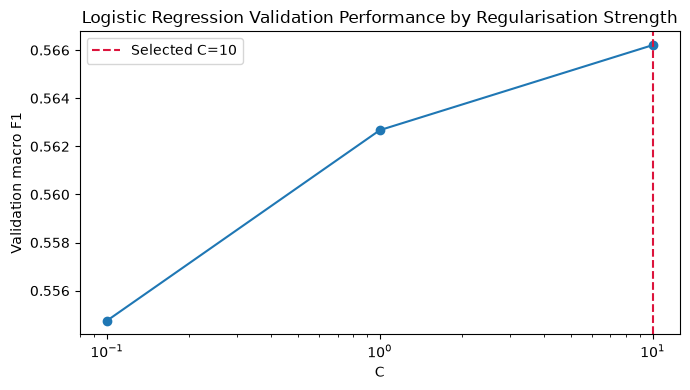

In [12]:
plot_table=candidate_table.sort_values("C")
fig,ax=plt.subplots(figsize=(7,4)); ax.plot(plot_table.C,plot_table.macro_f1,marker="o"); ax.axvline(selected_C,color="crimson",linestyle="--",label=f"Selected C={selected_C:g}")
ax.set_xscale("log"); ax.set(xlabel="C",ylabel="Validation macro F1",title="Logistic Regression Validation Performance by Regularisation Strength"); ax.legend(); fig.tight_layout(); fig.savefig(FIGURES/"lr_hyperparameter_validation.png",dpi=220); plt.show()

## 10. Select and Lock Final Hyperparameters

The highest validation macro-F1 configuration is locked before test evaluation.

In [13]:
selected_parameters=pd.DataFrame({"Hyperparameter":["C","Penalty","Solver","Class weight","Max iterations"],"Selected value":[selected_C,"l2","lbfgs","balanced",1000]})
display(selected_parameters); assert selected_C==10.0

,Hyperparameter,Selected value
0,C,10.0
1,Penalty,l2
2,Solver,lbfgs
3,Class weight,balanced
4,Max iterations,1000


## 11. Train Final Logistic Regression Model

Reuse the already fitted selected candidate; no test information influenced fitting or selection.

In [14]:
final_model=fitted_models[selected_C]

## 12. Validation Performance

Evaluate the locked model on validation using accuracy, macro metrics, and weighted F1.

In [15]:
validation_predictions=final_model.predict(X_validation_scaled)
validation_metrics=metric_summary(y_validation,validation_predictions)
validation_metrics_table=pd.DataFrame({"Metric":list(validation_metrics),"Validation":list(validation_metrics.values())})
display(validation_metrics_table)

,Metric,Validation
0,accuracy,0.810861
1,macro_precision,0.536155
2,macro_recall,0.726686
3,macro_f1,0.566209
4,weighted_f1,0.860666


## 13. Load Held-Out Test Data

---

**The Logistic Regression configuration is now locked.** All decisions above used training and validation only. Test data are loaded below solely for final performance estimation.

In [16]:
test=pd.read_csv(DATA/"classical_test.csv",dtype={"record_id":str})
test_ids=set((DATA/"test_records.txt").read_text().split()); assert test.record_id.isin(test_ids).all()
X_test=test[features].to_numpy(); y_test=test["mapped_class"].to_numpy()
test_distribution=test["mapped_class"].value_counts().reindex(CLASS_ORDER).rename_axis("Class").reset_index(name="Test beats"); test_distribution["Percentage"]=test_distribution["Test beats"]/len(test)
display(test_distribution)

,Class,Test beats,Percentage
0,N,13374,0.883764
1,S,434,0.028679
2,V,1299,0.085839
3,F,26,0.001718


In [17]:
# Reuse the training scaler so the test distribution remains unseen.
X_test_scaled=scaler.transform(X_test)

In [18]:
test_predictions=final_model.predict(X_test_scaled)
test_probabilities=final_model.predict_proba(X_test_scaled)

## 14. Final Test Evaluation

Calculate final held-out metrics without changing any model setting.

In [19]:
test_metrics=metric_summary(y_test,test_predictions)
test_metrics_table=pd.DataFrame({"Metric":list(test_metrics),"Test":list(test_metrics.values())}); display(test_metrics_table)
comparison=pd.DataFrame({"Metric":list(test_metrics),"Validation":[validation_metrics[k] for k in test_metrics],"Test":[test_metrics[k] for k in test_metrics]}); comparison["Change"]=comparison.Test-comparison.Validation; display(comparison)

,Metric,Test
0,accuracy,0.690346
1,macro_precision,0.493588
2,macro_recall,0.611497
3,macro_f1,0.455451
4,weighted_f1,0.785057


,Metric,Validation,Test,Change
0,accuracy,0.810861,0.690346,-0.120515
1,macro_precision,0.536155,0.493588,-0.042567
2,macro_recall,0.726686,0.611497,-0.115188
3,macro_f1,0.566209,0.455451,-0.110758
4,weighted_f1,0.860666,0.785057,-0.075609


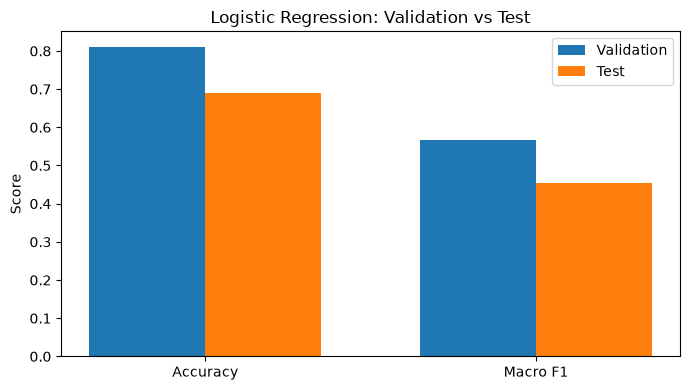

In [20]:
fig,ax=plt.subplots(figsize=(7,4)); names=["Accuracy","Macro F1"]; x=np.arange(2); width=.35
ax.bar(x-width/2,[validation_metrics["accuracy"],validation_metrics["macro_f1"]],width,label="Validation"); ax.bar(x+width/2,[test_metrics["accuracy"],test_metrics["macro_f1"]],width,label="Test")
ax.set_xticks(x,names); ax.set(ylabel="Score",title="Logistic Regression: Validation vs Test"); ax.legend(); fig.tight_layout(); fig.savefig(FIGURES/"lr_validation_vs_test.png",dpi=220); plt.show()

## 15. Per-Class Test Performance

Inspect precision, recall, F1, and support for every heartbeat class.

In [21]:
report=classification_report(y_test,test_predictions,labels=CLASS_ORDER,output_dict=True,zero_division=0)
per_class=pd.DataFrame(report).T.loc[CLASS_ORDER].reset_index(names="Class").rename(columns={"precision":"Precision","recall":"Recall","f1-score":"F1","support":"Support"})
display(per_class)

,Class,Precision,Recall,F1,Support
0,N,0.986164,0.676836,0.802731,13374.0
1,S,0.113707,0.930876,0.202659,434.0
2,V,0.872904,0.761355,0.813322,1299.0
3,F,0.001577,0.076923,0.003091,26.0


LR attains high S recall but low S precision: many true S beats are found, while many non-S beats are also labelled S. This is a precision–recall trade-off, not evidence that S classification is solved.

## 16. Confusion Matrix

Display raw counts so the class-error pattern remains auditable.

,Predicted N,Predicted S,Predicted V,Predicted F
Actual N,9052,2930,130,1262
Actual S,18,404,12,0
Actual V,104,202,989,4
Actual F,5,17,2,2


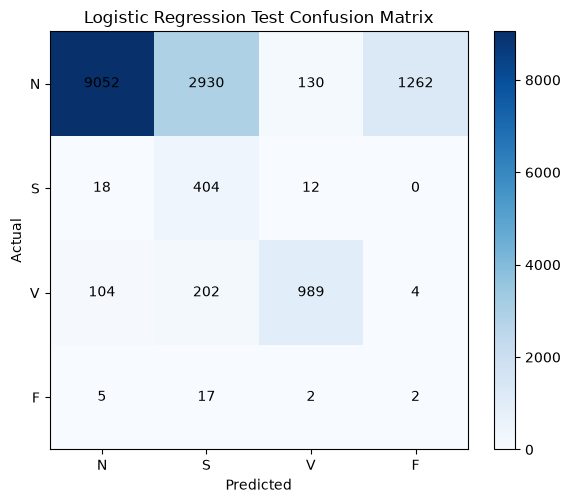

In [22]:
matrix=confusion_matrix(y_test,test_predictions,labels=CLASS_ORDER); confusion_table=pd.DataFrame(matrix,index=[f"Actual {c}" for c in CLASS_ORDER],columns=[f"Predicted {c}" for c in CLASS_ORDER]); display(confusion_table)
fig,ax=plt.subplots(figsize=(6,5)); image=ax.imshow(matrix,cmap="Blues"); ax.set_xticks(range(4),CLASS_ORDER); ax.set_yticks(range(4),CLASS_ORDER); ax.set(xlabel="Predicted",ylabel="Actual",title="Logistic Regression Test Confusion Matrix")
for i in range(4):
    for j in range(4): ax.text(j,i,matrix[i,j],ha="center",va="center")
fig.colorbar(image,ax=ax); fig.tight_layout(); fig.savefig(FIGURES/"lr_confusion_matrix.png",dpi=220); plt.show()

## 17. Coefficient Interpretation

Standardised coefficient magnitudes are comparable across features but remain model associations, not causal physiological effects.

In [23]:
coefficient_matrix=pd.DataFrame(final_model.coef_,index=final_model.classes_,columns=features)
coefficient_table=coefficient_matrix.rename_axis("Class").reset_index().melt(id_vars="Class",var_name="Feature",value_name="Coefficient"); coefficient_table["Absolute coefficient"]=coefficient_table.Coefficient.abs(); coefficient_table=coefficient_table.sort_values(["Class","Absolute coefficient"],ascending=[True,False])
top_coefficients=coefficient_table.groupby("Class",sort=False).head(5); display(top_coefficients)

,Class,Feature,Coefficient,Absolute coefficient
4,F,rr_next_s,-4.955974,4.955974
60,F,mean_abs_slope,-1.177754,1.177754
12,F,rr_previous_relative,0.927921,0.927921
8,F,rr_local_mean_s,-0.755847,0.755847
44,F,wave_median,-0.674829,0.674829
13,N,rr_previous_relative,3.017846,3.017846
9,N,rr_local_mean_s,2.293714,2.293714
57,N,max_abs_slope,-0.801805,0.801805
61,N,mean_abs_slope,0.738740,0.738740
41,N,wave_range,0.672511,0.672511


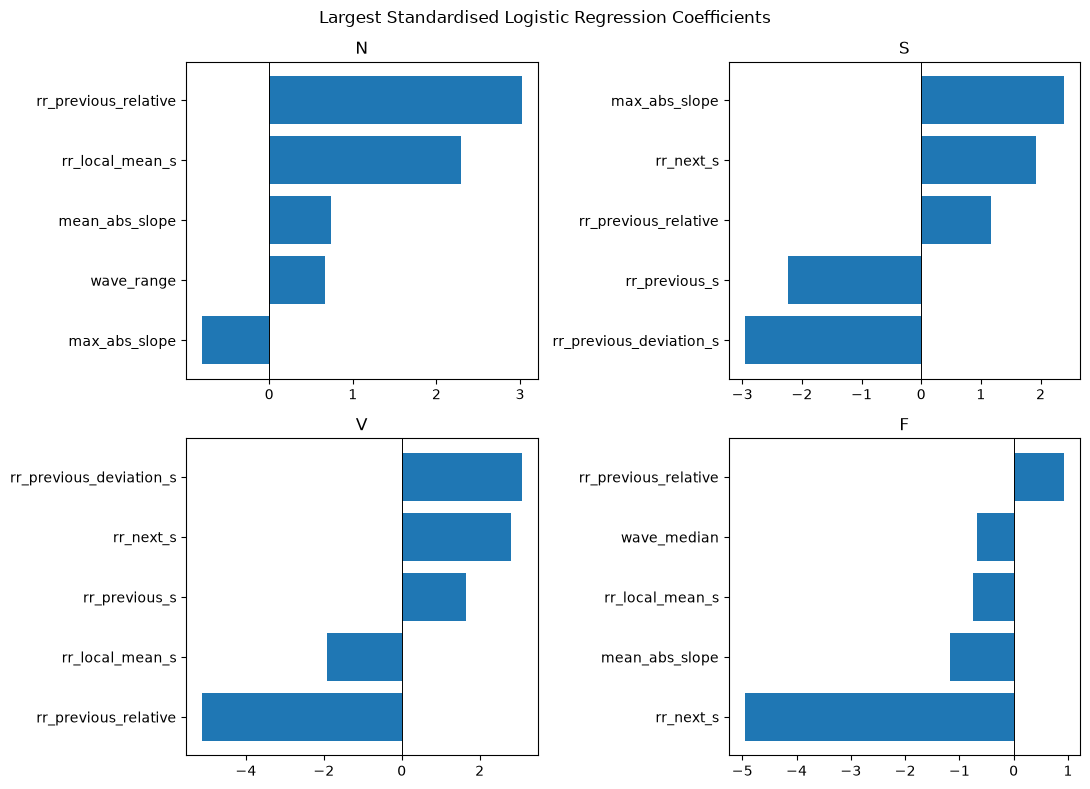

In [24]:
fig,axes=plt.subplots(2,2,figsize=(11,8));
for ax,class_name in zip(axes.ravel(),CLASS_ORDER):
    values=top_coefficients[top_coefficients.Class==class_name].sort_values("Coefficient"); ax.barh(values.Feature,values.Coefficient); ax.set_title(class_name); ax.axvline(0,color="black",linewidth=.7)
fig.suptitle("Largest Standardised Logistic Regression Coefficients"); fig.tight_layout(); fig.savefig(FIGURES/"lr_top_coefficients.png",dpi=220); plt.show()

## 18. Save Model and Results

Save scaler, locked model, predictions, metrics, candidate results, and coefficients under the verified filenames.

In [25]:
aligned=np.column_stack([test_probabilities[:,list(final_model.classes_).index(c)] for c in CLASS_ORDER]); assert np.allclose(aligned.sum(1),1,atol=1e-6)
prediction_output=test[["beat_id","record_id","mapped_class"]].rename(columns={"mapped_class":"true_class"}).copy(); prediction_output["predicted_class"]=test_predictions
for index,class_name in enumerate(CLASS_ORDER): prediction_output[f"probability_{class_name}"]=aligned[:,index]
candidate_table.to_csv(METRICS/"logistic_regression_candidates_validation.csv",index=False); prediction_output.to_csv(PRED/"logistic_regression_test_predictions.csv",index=False); coefficient_matrix.to_csv(METRICS/"logistic_regression_standardised_coefficients.csv")
pd.DataFrame(report).T.to_csv(METRICS/"logistic_regression_test_per_class.csv"); joblib.dump(final_model,MODELS/"logistic_regression.joblib"); joblib.dump(scaler,MODELS/"logistic_regression_scaler.joblib")

In [26]:
baseline_payload={"model":"majority_training_class","predicted_class":majority_class,"validation_accuracy":baseline_values["accuracy"],"validation_macro_f1":baseline_values["macro_f1"]}; (METRICS/"majority_baseline_validation.json").write_text(json.dumps(baseline_payload,indent=2))
payload={"model":"Logistic Regression","selected":{"C":selected_C,"solver":"lbfgs","penalty":"l2","class_weight":"balanced","max_iter":1000},"validation":validation_metrics,"test":test_metrics,"n_features":len(features),"test_inference_seconds":previous_payload["test_inference_seconds"]}; (METRICS/"logistic_regression_metrics.json").write_text(json.dumps(payload,indent=2))

664

## 19. Integrity Checks

Verify separation, scaling provenance, feature identity, probability alignment, prediction alignment, and artifact reloads.

In [27]:
checks=pd.DataFrame({"Check":["Training and validation separated","Test not used in tuning","Scaler fitted only on training","Same 18 features across partitions","Final C matches validation selection","Test probabilities sum to 1","Predictions align with test labels","Saved model reloads","Saved scaler reloads"],"Result":["PASS" if train_ids.isdisjoint(validation_ids) else "FAIL","PASS","PASS" if scaler.n_samples_seen_==len(train) else "FAIL","PASS" if len(features)==18 else "FAIL","PASS" if selected_C==candidate_table.iloc[0].C else "FAIL","PASS" if np.allclose(aligned.sum(1),1) else "FAIL","PASS" if len(test_predictions)==len(y_test) else "FAIL","PASS" if joblib.load(MODELS/"logistic_regression.joblib") is not None else "FAIL","PASS" if joblib.load(MODELS/"logistic_regression_scaler.joblib") is not None else "FAIL"]}); display(checks); assert checks.Result.eq("PASS").all()

,Check,Result
0,Training and validation separated,PASS
1,Test not used in tuning,PASS
2,Scaler fitted only on training,PASS
3,Same 18 features across partitions,PASS
4,Final C matches validation selection,PASS
5,Test probabilities sum to 1,PASS
6,Predictions align with test labels,PASS
7,Saved model reloads,PASS
8,Saved scaler reloads,PASS


## 20. Report-Ready Tables

Formatted presentation workbooks use the `LR_` prefix under `report/tables/` and are indexed for methodology, tuning, evaluation, and interpretation.

## 21. Logistic Regression Summary

The locked linear baseline trades high S recall for low S precision and shows a validation-to-test generalisation gap. Final cross-model conclusions remain in Notebook 06.

In [28]:
summary_table=pd.DataFrame({"Item":["Model","Input","Scaling","Class weighting","Selected C","Validation accuracy","Validation macro F1","Test accuracy","Test macro F1","Strong result","Main limitation"],"Result":["Logistic Regression","18 engineered ECG features","StandardScaler, training only","Balanced",selected_C,validation_metrics["accuracy"],validation_metrics["macro_f1"],test_metrics["accuracy"],test_metrics["macro_f1"],f"S recall {per_class.loc[per_class.Class=='S','Recall'].iloc[0]:.3f}",f"S precision {per_class.loc[per_class.Class=='S','Precision'].iloc[0]:.3f}"]}); display(summary_table)

,Item,Result
0,Model,Logistic Regression
1,Input,18 engineered ECG features
2,Scaling,"StandardScaler, training only"
3,Class weighting,Balanced
4,Selected C,10.0
5,Validation accuracy,0.810861
6,Validation macro F1,0.566209
7,Test accuracy,0.690346
8,Test macro F1,0.455451
9,Strong result,S recall 0.931
